In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tqdm import tqdm
import psutil
import random
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score, 
                             precision_score, recall_score, average_precision_score, 
                             brier_score_loss, confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

from model import WeatherLSTM
from model import WeatherRNN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

N_EPOCH = 10
N_SPLITS = 3

DATA_PATH = '../weatherAUS_clean_features.csv'
SVG_MODEL_PATH = 'weather_model.pth'

TYPE_LSTM = "LSTM"
TYPE_RNN = "RNN"
SEQ_LENGTH = 7 

CURRENT_TYPE = WeatherLSTM

## Prep

In [2]:
df = pd.read_csv(DATA_PATH) 

le_city = LabelEncoder()
df['Location'] = le_city.fit_transform(df['Location'])

le_rain = LabelEncoder()
df['RainTomorrow_enc'] = le_rain.fit_transform(df['RainTomorrow_enc'])

features_cols = [
    'Location', 'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos',
    'MinTemp', 'MaxTemp', 'TempRange', 'Rainfall', 'RainToday_bin',
    'Humidity3pm', 'HumidityChange', 'Pressure3pm', 'PressureChange',
    'WindGustSpeed', 'WindSpeedMean', 'Rainfall_roll7', 'MaxTemp_roll7',
    'Humidity3pm_roll7', 'StormFlag'
]

scaler = StandardScaler()
df[features_cols] = scaler.fit_transform(df[features_cols])

target_temp = 'MaxTemp'
target_rain = 'RainTomorrow_enc'

In [3]:
def create_sequences_by_city(df, seq_length):
    X, yt, yr = [], [], []
    for city, group in df.groupby('Location'):
        data = group[features_cols].values
        temp = group[target_temp].values
        rain = group[target_rain].values
        for i in range(len(data) - seq_length):
            X.append(data[i:i+seq_length])
            yt.append(temp[i+seq_length])
            yr.append(rain[i+seq_length])
    return np.array(X), np.array(yt), np.array(yr)

X_s, yt_s, yr_s = create_sequences_by_city(df, 3)
X_s, yt_s, yr_s = create_sequences_by_city(df, SEQ_LENGTH)

split_idx = int(0.8 * len(X_s))
X_train_raw = X_s[:split_idx]
yr_train_raw = yr_s[:split_idx]

num_neg = (yr_train_raw == 0).sum()
num_pos = (yr_train_raw == 1).sum()

weight_factor = 0.75
pos_weight = torch.tensor([(num_neg / num_pos) * weight_factor], dtype=torch.float32).to(device)

print(f"Ratio brut : {num_neg/num_pos:.2f} | Poids appliqué : {pos_weight.item():.2f}")

# tensors
X_train = torch.tensor(X_train_raw, dtype=torch.float32).permute(0, 2, 1).to(device)
yt_train = torch.tensor(yt_s[:split_idx], dtype=torch.float32).view(-1, 1).to(device)
yr_train = torch.tensor(yr_train_raw, dtype=torch.float32).view(-1, 1).to(device)

X_val = torch.tensor(X_s[split_idx:], dtype=torch.float32).permute(0, 2, 1).to(device)
yt_val = torch.tensor(yt_s[split_idx:], dtype=torch.float32).view(-1, 1).to(device)
yr_val = torch.tensor(yr_s[split_idx:], dtype=torch.float32).view(-1, 1).to(device)

train_loader = DataLoader(TensorDataset(X_train, yt_train, yr_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, yt_val, yr_val), batch_size=64, shuffle=False)

Ratio brut : 3.41 | Poids appliqué : 2.55


# Hyperparametre

In [4]:
def compute_metrics(all_labels, all_logits):
    logits_tensor = torch.tensor(np.array(all_logits))
    
    probs = torch.sigmoid(logits_tensor).numpy()
    preds = (probs > 0.5).astype(float)
    labels = np.array(all_labels)
    
    return {
        "roc_auc": roc_auc_score(labels, probs),
        "f1": f1_score(labels, preds),
        "acc": accuracy_score(labels, preds),
        "prec": precision_score(labels, preds, zero_division=0),
        "rec": recall_score(labels, preds)
    }

In [26]:
def evaluate_model_config(model_type, config, X_s, yt_s, yr_s, features_cols):
    """Teste une config pour un type de modèle précis (RNN ou LSTM)."""
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    fold_aucs = []

    for train_index, val_index in tscv.split(X_s):
        # Séparation Train/Val
        X_train, X_val = X_s[train_index], X_s[val_index]
        yr_train, yr_val = yr_s[train_index], yr_s[val_index]
        yt_train, yt_val = yt_s[train_index], yt_s[val_index]

        # DataLoaders
        train_ds = TensorDataset(
            torch.tensor(X_train, dtype=torch.float32).permute(0, 2, 1).to(device),
            torch.tensor(yt_train, dtype=torch.float32).view(-1, 1).to(device),
            torch.tensor(yr_train, dtype=torch.float32).view(-1, 1).to(device)
        )
        val_loader = DataLoader(TensorDataset(
            torch.tensor(X_val, dtype=torch.float32).permute(0, 2, 1).to(device),
            torch.tensor(yt_val, dtype=torch.float32).view(-1, 1).to(device),
            torch.tensor(yr_val, dtype=torch.float32).view(-1, 1).to(device)
        ), batch_size=config['batch_size'])

        train_loader = DataLoader(train_ds, batch_size=config['batch_size'], shuffle=False)

        # Initialisation du modèle spécifique
        if model_type == "LSTM":
            model = WeatherLSTM(len(features_cols), config['hidden_size'], config['num_layers']).to(device)
        else:
            model = WeatherRNN(len(features_cols), config['hidden_size'], config['num_layers']).to(device)

        optimizer = optim.Adam(model.parameters(), lr=config['lr'])
        bce_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        mse_loss = nn.MSELoss()

        best_auc_this_fold = 0
        for epoch in range(min(N_EPOCH, 10)): # Recherche rapide sur 10 epochs max
            model.train()
            for b_x, b_yt, b_yr in train_loader:
                optimizer.zero_grad()
                p_temp, p_rain_logits = model(b_x)
                loss = mse_loss(p_temp, b_yt) + bce_loss(p_rain_logits, b_yr)
                loss.backward()
                optimizer.step()

            model.eval()
            val_labels, val_logits = [], []
            with torch.no_grad():
                for bv_x, _, bv_yr in val_loader:
                    _, pv_rain_logits = model(bv_x)
                    val_labels.extend(bv_yr.cpu().numpy())
                    val_logits.extend(pv_rain_logits.cpu().numpy())
            
            res = compute_metrics(val_labels, val_logits)
            best_auc_this_fold = max(best_auc_this_fold, res['auc'])
        
        fold_aucs.append(best_auc_this_fold)
        
    return np.mean(fold_aucs)

In [27]:
param_grid = {
    'lr': [0.001, 0.0005, 0.0001],
    'hidden_size': [32, 64, 128],
    'num_layers': [1, 2],
    'batch_size': [32, 64]
}

N_ITER = 3 # Nombre de tests par architecture (ex: 3 pour RNN, 3 pour LSTM)
configs_finales = {}

for m_type in ["RNN", "LSTM"]:
    print(f"\n" + "#"*50)
    print(f" RECHERCHE D'HYPERPARAMÈTRES POUR : {m_type}")
    print("#"*50)
    
    best_auc = -1
    best_config = None
    
    for i in range(N_ITER):
        config = {k: random.choice(v) for k, v in param_grid.items()}
        print(f"\n--- {m_type} | Essai {i+1}/{N_ITER} ---")
        print(f"Test de: {config}")
        
        try:
            score = evaluate_model_config(m_type, config, X_s, yt_s, yr_s, features_cols)
            print(f"Résultat AUC moyen : {score:.4f}")
            
            if score > best_auc:
                best_auc = score
                best_config = config
        except Exception as e:
            print(f"Erreur durant l'essai : {e}")

    configs_finales[m_type] = {'config': best_config, 'auc': best_auc}


##################################################
 RECHERCHE D'HYPERPARAMÈTRES POUR : RNN
##################################################

--- RNN | Essai 1/3 ---
Test de: {'lr': 0.0001, 'hidden_size': 32, 'num_layers': 2, 'batch_size': 32}
Résultat AUC moyen : 0.7077

--- RNN | Essai 2/3 ---
Test de: {'lr': 0.0001, 'hidden_size': 128, 'num_layers': 2, 'batch_size': 32}
Résultat AUC moyen : 0.7185

--- RNN | Essai 3/3 ---
Test de: {'lr': 0.001, 'hidden_size': 32, 'num_layers': 1, 'batch_size': 64}
Résultat AUC moyen : 0.7096

##################################################
 RECHERCHE D'HYPERPARAMÈTRES POUR : LSTM
##################################################

--- LSTM | Essai 1/3 ---
Test de: {'lr': 0.001, 'hidden_size': 32, 'num_layers': 1, 'batch_size': 32}
Résultat AUC moyen : 0.7084

--- LSTM | Essai 2/3 ---
Test de: {'lr': 0.0005, 'hidden_size': 32, 'num_layers': 2, 'batch_size': 32}
Résultat AUC moyen : 0.7153

--- LSTM | Essai 3/3 ---
Test de: {'lr': 0.0001, 'hidden

In [28]:
print("\n\n" + "="*50)
print("RÉSULTATS DE L'OPTIMISATION")
print(f"MEILLEUR RNN  : {configs_finales['RNN']['auc']:.4f} -> {configs_finales['RNN']['config']}")
print(f"MEILLEUR LSTM : {configs_finales['LSTM']['auc']:.4f} -> {configs_finales['LSTM']['config']}")
print("="*50)

# Variables à utiliser pour vos entraînements finaux :
config_rnn_opti = configs_finales['RNN']['config']
config_lstm_opti = configs_finales['LSTM']['config']



RÉSULTATS DE L'OPTIMISATION
MEILLEUR RNN  : 0.7185 -> {'lr': 0.0001, 'hidden_size': 128, 'num_layers': 2, 'batch_size': 32}
MEILLEUR LSTM : 0.7153 -> {'lr': 0.0005, 'hidden_size': 32, 'num_layers': 2, 'batch_size': 32}


# Entrainement

In [5]:
configs_finales = {
    'RNN': {
        'config': {'lr': 0.0005, 'hidden_size': 64, 'num_layers': 1, 'batch_size': 32},
        'auc': 0.7098
    },
    'LSTM': {
        'config': {'lr': 0.0001, 'hidden_size': 128, 'num_layers': 2, 'batch_size': 32},
        'auc': 0.7232
    }
}

In [6]:
import os
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from torch.utils.data import DataLoader, TensorDataset

SAVE_DIR = "saved_models"
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

model_types = ["RNN", "LSTM"]
all_model_summaries = []
patience = 5

for current_type in model_types:
    best_config = configs_finales[current_type]['config']
    print("═"*50)
    print(f"ENTRAÎNEMENT DU MODÈLE : {current_type:15}")
    print(f"CONFIG OPTIMALE : {best_config}")
    print("═"*50)

    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    fold_results = []

    for fold, (train_index, val_index) in enumerate(tscv.split(X_s)):
        print(f"\n--- {current_type} | FOLD {fold + 1}/{N_SPLITS} ---")

        X_train_f, X_val_f = X_s[train_index], X_s[val_index]
        yt_train_f, yt_val_f = yt_s[train_index], yt_s[val_index]
        yr_train_f, yr_val_f = yr_s[train_index], yr_s[val_index]

        train_ds = TensorDataset(
            torch.tensor(X_train_f, dtype=torch.float32).permute(0, 2, 1).to(device),
            torch.tensor(yt_train_f, dtype=torch.float32).view(-1, 1).to(device),
            torch.tensor(yr_train_f, dtype=torch.float32).view(-1, 1).to(device)
        )
        val_ds = TensorDataset(
            torch.tensor(X_val_f, dtype=torch.float32).permute(0, 2, 1).to(device),
            torch.tensor(yt_val_f, dtype=torch.float32).view(-1, 1).to(device),
            torch.tensor(yr_val_f, dtype=torch.float32).view(-1, 1).to(device)
        )

        train_loader = DataLoader(train_ds, batch_size=best_config['batch_size'], shuffle=False)
        val_loader = DataLoader(val_ds, batch_size=best_config['batch_size'], shuffle=False)

        if current_type == "LSTM":
            model = WeatherLSTM(len(features_cols), 
                                hidden_size=best_config['hidden_size'], 
                                num_layers=best_config['num_layers']).to(device)
        else:
            model = WeatherRNN(len(features_cols), 
                               hidden_size=best_config['hidden_size'], 
                               num_layers=best_config['num_layers']).to(device)

        optimizer = optim.Adam(model.parameters(), lr=best_config['lr'])
        mse_loss = nn.MSELoss()
        bce_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        best_val_auc_fold = 0
        counter = 0

        # Boucle d'entraînement (inchangée)
        for epoch in range(N_EPOCH):
            model.train()
            train_labels, train_logits = [], []
            pbar = tqdm(train_loader, desc=f"{current_type} | F{fold+1} | Ep {epoch+1:02d}", leave=False)
            
            for b_x, b_yt, b_yr in pbar:
                optimizer.zero_grad()
                p_temp, p_rain_logits = model(b_x)
                loss = mse_loss(p_temp, b_yt) + bce_loss(p_rain_logits, b_yr)
                loss.backward()
                optimizer.step()
                
                train_labels.extend(b_yr.cpu().numpy())
                train_logits.extend(p_rain_logits.detach().cpu().numpy())

            model.eval()
            val_labels, val_logits = [], []
            with torch.no_grad():
                for bv_x, bv_yt, bv_yr in val_loader:
                    _, pv_rain_logits = model(bv_x)
                    val_labels.extend(bv_yr.cpu().numpy())
                    val_logits.extend(pv_rain_logits.cpu().numpy())

            m_train = compute_metrics(train_labels, train_logits)
            m_val = compute_metrics(val_labels, val_logits)
            
            if (epoch + 1) % 5 == 0 or epoch == 0:
                print(f" Acc: {m_val['acc']:.4f} | ROC-AUC: {m_val['roc_auc']:.4f} | F1: {m_val['f1']:.4f} | Prec: {m_val['prec']:.4f} | Rec: {m_val['rec']:.4f}")
            
            if m_val['roc_auc'] > best_val_auc_fold:
                best_val_auc_fold = m_val['roc_auc']
                counter = 0 # Reset le counter si on progresse
                model_path = os.path.join(SAVE_DIR, f"{current_type}_fold{fold+1}.pth")
                checkpoint = {
                    'model_state_dict': model.state_dict(),
                    'config': best_config, # Sauvegarder aussi la config utilisée
                    'val_auc': best_val_auc_fold,
                    'model_type': current_type
                }
                torch.save(checkpoint, model_path)
            else:
                counter += 1
                if counter >= patience: break

        fold_results.append(best_val_auc_fold)

    all_model_summaries.append({
        'Modèle': current_type,
        'Mean AUC': np.mean(fold_results),
        'Std AUC': np.std(fold_results)
    })

# Comparaison finale (inchangée)
summary_df = pd.DataFrame(all_model_summaries)
print("\nCOMPARAISON FINALE DES ARCHITECTURES")
print(summary_df.to_string(index=False))

══════════════════════════════════════════════════
ENTRAÎNEMENT DU MODÈLE : RNN            
CONFIG OPTIMALE : {'lr': 0.0005, 'hidden_size': 64, 'num_layers': 1, 'batch_size': 32}
══════════════════════════════════════════════════

--- RNN | FOLD 1/3 ---


 Acc: 0.6980 | ROC-AUC: 0.6873 | F1: 0.4315 | Prec: 0.3888 | Rec: 0.4848


 Acc: 0.6970 | ROC-AUC: 0.7048 | F1: 0.4348 | Prec: 0.3888 | Rec: 0.4932


 Acc: 0.6982 | ROC-AUC: 0.7042 | F1: 0.4382 | Prec: 0.3912 | Rec: 0.4980

--- RNN | FOLD 2/3 ---


 Acc: 0.6872 | ROC-AUC: 0.6985 | F1: 0.4406 | Prec: 0.3713 | Rec: 0.5418


...

 Acc: 0.6878 | ROC-AUC: 0.7175 | F1: 0.4630 | Prec: 0.3803 | Rec: 0.5919


 Acc: 0.6605 | ROC-AUC: 0.7261 | F1: 0.4774 | Prec: 0.3672 | Rec: 0.6820

--- LSTM | FOLD 3/3 ---


 Acc: 0.7611 | ROC-AUC: 0.6458 | F1: 0.2030 | Prec: 0.3779 | Rec: 0.1388


 Acc: 0.7004 | ROC-AUC: 0.7086 | F1: 0.4442 | Prec: 0.3744 | Rec: 0.5459


 Acc: 0.7053 | ROC-AUC: 0.7194 | F1: 0.4541 | Prec: 0.3824 | Rec: 0.5590

COMPARAISON FINALE DES ARCHITECTURES
Modèle  Mean AUC  Std AUC
   RNN  0.709829 0.006634
  LSTM  0.722950 0.002891


# Resultats

C:\Users\thiba\AppData\Local\Temp\ipykernel_14000\2189615551.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=devic

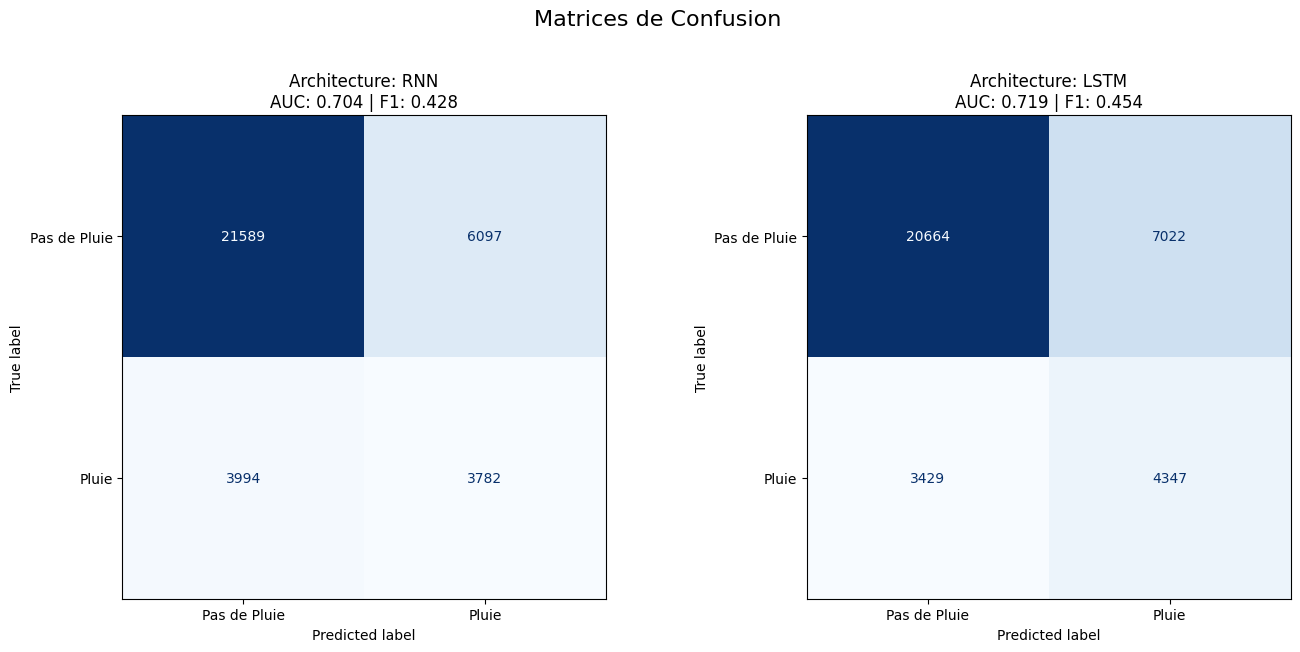

In [7]:
def get_final_metrics(model, loader, device):
    model.eval()
    all_labels = []
    all_logits = []
    
    with torch.no_grad():
        for b_x, _, b_yr in loader:
            _, p_rain_logits = model(b_x.to(device))
            all_labels.extend(b_yr.cpu().numpy())
            all_logits.extend(p_rain_logits.cpu().numpy())
    
    probs = torch.sigmoid(torch.tensor(all_logits)).numpy()
    preds = (probs >= 0.5).astype(int)
    labels = np.array(all_labels).astype(int)
    
    metrics = {
        "ROC-AUC": roc_auc_score(labels, probs),
        "Accuracy": accuracy_score(labels, preds),
        "F1": f1_score(labels, preds),
        "Precision": precision_score(labels, preds),
        "Recall": recall_score(labels, preds),
        "Avg-AP": average_precision_score(labels, probs),
        "Brier": brier_score_loss(labels, probs)
    }
    
    return metrics, labels, preds

models_to_compare = [TYPE_RNN, TYPE_LSTM]

fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 

for i, m_type in enumerate(models_to_compare):
    checkpoint_path = os.path.join(SAVE_DIR, f"{m_type}_fold{N_SPLITS}.pth")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    saved_config = checkpoint.get('config')

    if m_type == TYPE_LSTM:
        model_eval = WeatherLSTM(
            num_features=len(features_cols),  # Changé input_size -> num_features
            hidden_size=saved_config['hidden_size'], 
            num_layers=saved_config['num_layers']
        ).to(device)
    else:
        model_eval = WeatherRNN(
            num_features=len(features_cols),  # Changé input_size -> num_features
            hidden_size=saved_config['hidden_size'], 
            num_layers=saved_config['num_layers']
        ).to(device)
    
    model_eval.load_state_dict(checkpoint['model_state_dict'])
    
    metrics, labels, preds = get_final_metrics(model_eval, val_loader, device)
    
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pas de Pluie', 'Pluie'])
    
    disp.plot(cmap='Blues', ax=axes[i], colorbar=False)
    
    axes[i].set_title(f"Architecture: {m_type}\nAUC: {metrics['ROC-AUC']:.3f} | F1: {metrics['F1']:.3f}")

plt.tight_layout()
plt.suptitle("Matrices de Confusion", fontsize=16, y=1.08)
plt.show()